# 12 · Embodied — a policy in a closed loop

A small neural policy, cloned from an oracle, plays a grid game through the unified
interface: render a frame, select a move, step, repeat. It is evaluated against an oracle
ceiling and a random-policy floor, and its activations are captured at each tick.

The board denotes the player as **P** and the goal as **G**, with four actions
corresponding to up, down, left and right. Two metrics are reported over 20 fresh games:
**success_rate**, the fraction reaching the goal, and **efficiency**, defined as
optimal_steps / steps_taken, where 1.0 indicates an optimal path.

On a board this small a random walk reaches the goal reasonably often, so success_rate
separates the policies weakly. Efficiency is the discriminating metric: a competent
policy takes near-optimal paths, approaching the oracle's 1.0, while a random policy
wanders well below.

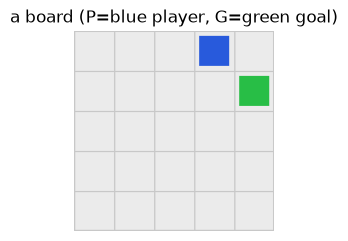

. . . P .
. . . . G
. . . . .
. . . . .
. . . . .


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
from brainscore.harnesses.grid_game import (GridGameEnv, play_game,
    greedy_oracle_policy, random_action_policy, evaluate_policy)
from brainscore.model_helpers.policy_wrapper import PolicyWrapper
from brainscore.activation_window import ActivationWindow
from brainscore_core.model_interface import BrainScoreModel
torch.manual_seed(0); np.random.seed(0)   # fixed seeds so the whole notebook is reproducible

# Spin up one game and render its opening board: a frame (pixels) plus an ascii view.
env = GridGameEnv(size=5, seed=3); obs = env.reset()
plt.figure(figsize=(2.6, 2.6)); plt.imshow(obs['frame']); plt.axis('off')
plt.title('a board (P=blue player, G=green goal)'); plt.show()
print(obs['ascii'])

## Clone the oracle into a small conv net

Behavior-clone the oracle's frame -> action mapping, then wrap the net as a subject via `action_fn`.

In [2]:
# A small convolutional network that looks at the board and picks a move.
class TinyPolicyNet(nn.Module):
    def __init__(self, n_actions=4):
        super().__init__()
        # Two conv layers shrink the image; the pool fixes the output at 6x6
        # so the final layer always sees the same number of numbers.
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, 2, 1), nn.ReLU(),
            nn.AdaptiveMaxPool2d((6, 6)))
        # One score per action (up/down/left/right). Highest score wins.
        self.head = nn.Linear(16 * 6 * 6, n_actions)
    def forward(self, x):
        return self.head(self.features(x).flatten(1))   # flatten the grid, then score

net = TinyPolicyNet()

def frame_to_tensor(f):
    '''Turn a board image into the shape the net expects.'''
    t = torch.from_numpy(np.ascontiguousarray(f)).float()
    t = t.permute(2, 0, 1)      # (height, width, colour) -> (colour, height, width)
    return t.unsqueeze(0) / 255.  # add a batch dimension; scale 0-255 to 0-1

# Build training data by watching a perfect player ("the oracle") play 150 games.
# X = the board it saw, Y = the move it made.
X, Y = [], []
for ep in range(150):
    e = GridGameEnv(size=5, seed=1000 + ep); o = e.reset()
    for _ in range(e.max_steps):
        a = greedy_oracle_policy(o, ())
        X.append(frame_to_tensor(o['frame'])); Y.append(a)
        o, _, done, _ = e.step(a)
        if done: break
X = torch.cat(X); Y = torch.tensor(Y)

# Train the net to copy the oracle. This is "behaviour cloning": no rewards,
# just learning to output the same move the expert did.
opt = torch.optim.Adam(net.parameters(), lr=2e-3); net.train()
for _ in range(15):                               # 15 passes over the data
    perm = torch.randperm(len(Y))                 # shuffle so batches differ each pass
    for i in range(0, len(Y), 64):                # train on 64 examples at a time
        idx = perm[i:i + 64]
        loss = nn.functional.cross_entropy(net(X[idx]), Y[idx])   # prediction error
        opt.zero_grad()      # clear last step's gradients
        loss.backward()      # work out which way each weight should move
        opt.step()           # move them
net.eval()

# How often the trained net picks the same move the oracle did.
imit_acc = float((net(X).argmax(1) == Y).float().mean())
print(f'cloned on {len(Y)} oracle states; imitation accuracy {imit_acc:.2f} (fraction of frames where the net picks the oracle move)')

cloned on 490 oracle states; imitation accuracy 0.96 (fraction of frames where the net picks the oracle move)


## Two neural policies: pure and cycle-escape

A pure clone is deterministic and can wedge, revisiting a state and looping indefinitely.
Adding a cycle-escape, a random legal move taken only when a state repeats, is a separate
and explicitly disclosed heuristic. Both are reported.

In [3]:
def neural_pure(observation, history):
    '''Always play the move the net scores highest.'''
    with torch.no_grad():                       # predicting only, no training
        scores = net(frame_to_tensor(observation['frame']))
        return int(scores.argmax(1).item())     # argmax = index of the highest score

_esc = np.random.RandomState(0)

def neural_escape(observation, history):
    '''Same, but take a random legal move if the board has been seen before.

    A greedy player can get stuck walking between two squares forever. Spotting a
    repeat and moving randomly breaks the loop.
    '''
    with torch.no_grad():
        a = int(net(frame_to_tensor(observation['frame'])).argmax(1).item())
    seen_before = history and any(
        np.array_equal(o['frame'], observation['frame']) for o, _ in history)
    if seen_before:
        a = int(_esc.choice(list(observation['legal_actions'].keys())))
    return a

# Wrap any policy function as a Brain-Score subject. Passing it as action_fn is what
# lets process() drive it in a closed loop -- every policy below uses this same path.
mk = lambda p: BrainScoreModel('grid-policy', None, {}, {}, None,
                               action_fn=PolicyWrapper(p, max_history=4))

# Play the same 20 games with four policies, so the numbers are comparable.
res = {
    'oracle (ceiling)':   evaluate_policy(mk, greedy_oracle_policy, n_episodes=20),
    'random (floor)':     evaluate_policy(mk, random_action_policy(0), n_episodes=20),
    'neural, pure argmax': evaluate_policy(mk, neural_pure, n_episodes=20),
    'neural, +escape':    evaluate_policy(mk, neural_escape, n_episodes=20),
}
# success_rate = fraction of games solved. efficiency = how close to the shortest path.
for k, v in res.items():
    print(f"{k:20s} success_rate={v['success_rate']:.2f}  efficiency={v['mean_efficiency']:.2f}  (n=20)")

oracle (ceiling)     success_rate=1.00  efficiency=1.00  (n=20)
random (floor)       success_rate=0.60  efficiency=0.37  (n=20)
neural, pure argmax  success_rate=0.55  efficiency=0.91  (n=20)
neural, +escape      success_rate=0.90  efficiency=0.70  (n=20)


**Interpretation.** Efficiency is the discriminating metric. The pure clone takes
near-optimal paths at 0.91, close to the oracle's 1.00, but its lower success_rate of
0.55 reflects wedging: a deterministic policy can revisit a state and loop until timeout.
The random policy attains a higher success_rate of 0.60 by chance on a 5x5 board while
meandering when it arrives, at an efficiency of 0.37. The disclosed cycle-escape removes
the wedging, raising success_rate from 0.55 to 0.90, at an efficiency cost from 0.91 to
0.70, since a random escape step is rarely optimal. On path quality the neural policy
exceeds the floor; success_rate alone is confounded by wedging and by chance.

## Activation capture, one per tick

`ActivationWindow` records the `features` block. Each capture is spatially averaged to 16
channel means, and three conditions are compared: distinct boards, the same board
repeated as a determinism floor, and a live rollout.

In [4]:
def chan16(capture):
    '''Summarise one captured feature map as 16 numbers, one per channel.'''
    # The capture is (1, 16 channels, 6, 6). Average each channel's 36 values.
    return np.asarray(capture).reshape(16, -1).mean(1)

# Run 1: eight different boards. Features should differ between them.
frames = [GridGameEnv(size=5, seed=s).reset()['frame'] for s in range(8)]
with ActivationWindow(net, layers=['features']) as distinct:
    for f in frames:
        with torch.no_grad(): net(frame_to_tensor(f))

# Run 2: the SAME board eight times. Features should be identical -- this is the
# floor, establishing that variation observed elsewhere is caused by the input.
with ActivationWindow(net, layers=['features']) as same:
    for _ in range(8):
        with torch.no_grad(): net(frame_to_tensor(frames[0]))

# Run 3: a real game, capturing features at every tick as the agent plays.
with ActivationWindow(net, layers=['features']) as loop:
    result = play_game(mk(neural_escape), GridGameEnv(size=6, seed=3), max_steps=40)

# Stack each run into a table: one row per capture, 16 columns.
D = np.stack([chan16(c) for c in distinct.by_layer()['features']])
S = np.stack([chan16(c) for c in same.by_layer()['features']])
L = np.stack([chan16(c) for c in loop.by_layer()['features']])

# std = how much a channel varies across captures. High = responding to the input.
print(f'distinct boards: mean per-channel std {D.std(0).mean():.3f}  (responds to input)')
print(f'same board x8:   mean per-channel std {S.std(0).mean():.3f}  (determinism floor ~0)')
print(f'closed loop: solved={result["solved"]} in {result["steps"]} ticks; captures={len(L)} == actions={len(result["actions"])}')

distinct boards: mean per-channel std 0.023  (responds to input)
same board x8:   mean per-channel std 0.000  (determinism floor ~0)
closed loop: solved=True in 19 ticks; captures=19 == actions=19


## The captured activations

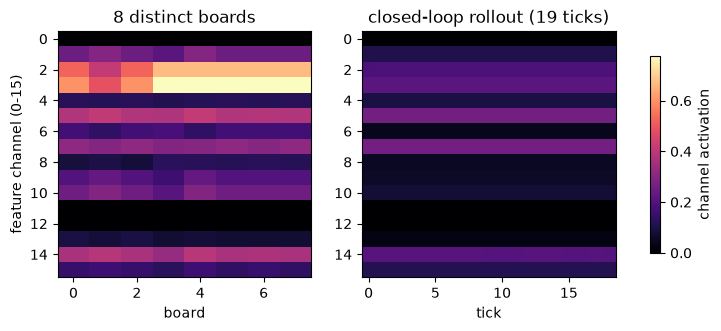

In [5]:
# Heatmaps of the two runs on a shared color scale: feature channels x captures.
vmax = float(max(D.max(), L.max())); vmin = float(min(D.min(), L.min()))
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
im = ax[0].imshow(D.T, aspect='auto', cmap='magma', vmin=vmin, vmax=vmax)
ax[0].set_title('8 distinct boards'); ax[0].set_xlabel('board'); ax[0].set_ylabel('feature channel (0-15)')
ax[1].imshow(L.T, aspect='auto', cmap='magma', vmin=vmin, vmax=vmax)
ax[1].set_title(f'closed-loop rollout ({len(L)} ticks)'); ax[1].set_xlabel('tick')
fig.colorbar(im, ax=ax, shrink=0.8, label='channel activation')
plt.show()

**Interpretation.** Each column is one capture and each row one of 16 feature channels,
on a shared colour scale. Across distinct boards the channels vary, indicating that the
network responds to board content. Repeating the same board produces approximately zero
variation, confirming determinism. The rollout traces the trajectory the policy took. The
same `action_fn` path runs the oracle, random and neural policies without per-policy
code.

In [6]:
# Confirm the typed environment-rollout helper is exposed on the public API.
from brainscore_core import streaming_helpers
print('typed run_environment helper available:', hasattr(streaming_helpers, 'run_environment'))

typed run_environment helper available: True
